### Imports

In [1]:
import os
import sys
import pickle
from skimage.io import imread
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
sys.path.append('/home/dafei/git/AutoDS3D/')
from DS3Dplus.ds3d_utils import calc_jaccard_rmse

### Functions

In [3]:
def plot_3d_localizations(image, xyz_gt, xyz_pred1, xyz_pred2,metrics1,metrics2, title, path, label1='Model 1 Predictions', label2='Model 2 Predictions'):
    fig,ax = plt.subplots(1,2,figsize=(16,8))
    ax[0].imshow(image, cmap='gray')
    #ax[0].set_title(title)
    ax[0].axis('off')
    ax[1] = fig.add_subplot(122, projection='3d')
    ax[1].scatter(xyz_gt[:, 0], xyz_gt[:, 1], xyz_gt[:, 2], c='g', marker='o', label='Ground Truth', alpha=0.5)
    ax[1].scatter(xyz_pred1[:, 0], xyz_pred1[:, 1], xyz_pred1[:, 2], c='b', marker='^', label=label1, alpha=0.5)
    ax[1].scatter(xyz_pred2[:, 0], xyz_pred2[:, 1], xyz_pred2[:, 2], c='r', marker='s', label=label2, alpha=0.5)
    if metrics1['Jaccard'] == 0.0:
        ax[1].text2D(0.05, 0.95, f"{label1} - Jaccard: {metrics1['Jaccard']}, RMSE_xy: {metrics1['RMSE_xy (nm)']} nm, RMSE_z: {metrics1['RMSE_z (nm)']} nm", transform=ax[1].transAxes, color='blue')
    else:
        ax[1].text2D(0.05, 0.95, f"{label1} - Jaccard: {metrics1['Jaccard']:.3f}, RMSE_xy: {metrics1['RMSE_xy (nm)']:.1f} nm, RMSE_z: {metrics1['RMSE_z (nm)']:.1f} nm", transform=ax[1].transAxes, color='blue')
    if metrics2['Jaccard'] == 0.0:
        ax[1].text2D(0.05, 0.90, f"{label2} - Jaccard: {metrics2['Jaccard']}, RMSE_xy: {metrics2['RMSE_xy (nm)']} nm, RMSE_z: {metrics2['RMSE_z (nm)']} nm", transform=ax[1].transAxes, color='red')
    else:
        ax[1].text2D(0.05, 0.90, f"{label2} - Jaccard: {metrics2['Jaccard']:.3f}, RMSE_xy: {metrics2['RMSE_xy (nm)']:.1f} nm, RMSE_z: {metrics2['RMSE_z (nm)']:.1f} nm", transform=ax[1].transAxes, color='red')
    ax[1].set_xlabel('X (um)')
    ax[1].set_ylabel('Y (um)')
    ax[1].set_zlabel('Z (um)')
    #ax[1].set_title(title)
    ax[1].legend()
    plt.savefig(path)
    plt.close()

In [4]:
def save_non_aberrated_image_comparison(x_folder, localizations, df_autods3d, df_vit, output_dir):
    # check image folder
    if os.path.basename(x_folder) != 'orig':
        raise ValueError(f"x_folder should be 'orig' folder containing non-aberrated images, got {x_folder}")
    for img_name in df_autods3d['Image'].unique():
        xyzps_gt = localizations[img_name]
        xyz_gt = xyzps_gt['xyzps'][:, :-1]
        image_path = os.path.join(x_folder, img_name)
        im = imread(image_path)
        xyz_pred_autods3d = df_autods3d[df_autods3d['Image'] == img_name][['x', 'y', 'z']].to_numpy()
        jaccard_autods3d, rmse_xy_autods3d, rmse_z_autods3d, _ = calc_jaccard_rmse(
                xyz_gt, xyz_pred_autods3d, 0.1)
        if jaccard_autods3d != 0.0:
            metrics_autods3d = {
                'Jaccard': jaccard_autods3d,
                'RMSE_xy (nm)': rmse_xy_autods3d*1000,
                'RMSE_z (nm)': rmse_z_autods3d*1000
            }
        else:
            metrics_autods3d = {
                'Jaccard': 0.0,
                'RMSE_xy (nm)': None,
                'RMSE_z (nm)': None
            }
        xyz_pred_vit = df_vit[df_vit['Image'] == img_name][['x', 'y', 'z']].to_numpy()
        jaccard_vit, rmse_xy_vit, rmse_z_vit, _ = calc_jaccard_rmse(
                xyz_gt, xyz_pred_vit, 0.1)
        if jaccard_vit != 0.0:
            metrics_vit = {
                'Jaccard': jaccard_vit,
                'RMSE_xy (nm)': rmse_xy_vit*1000,
                'RMSE_z (nm)': rmse_z_vit*1000
            }
        else:
            metrics_vit = {
                'Jaccard': 0.0,
                'RMSE_xy (nm)': None,
                'RMSE_z (nm)': None
            }
        path = os.path.join(output_dir, f"{img_name}_comparison.png")
        plot_3d_localizations(im, xyz_gt, xyz_pred_autods3d, xyz_pred_vit, metrics_autods3d, metrics_vit, img_name, path,
                            label1='AutoDS3D Predictions', label2='ViT Predictions')

In [33]:
def save_aberrated_image_comparison(x_folder, localizations, df_autods3d, df_vit, output_dir):
    # check image folder
    if os.path.basename(x_folder) != 'abr':
        raise ValueError(f"x_folder should be 'abr' folder containing non-aberrated images, got {x_folder}")
    for abr_img_name in df_autods3d['Image'].unique():
        img_name = abr_img_name[:-4]
        abr_img_name_on_disk = img_name.replace('.tif', '_abr.tif')
        xyzps_gt = localizations[img_name]
        xyz_gt = xyzps_gt['xyzps'][:, :-1]
        image_path = os.path.join(x_folder, abr_img_name_on_disk)
        im = imread(image_path)
        xyz_pred_autods3d = df_autods3d[df_autods3d['Image'] == abr_img_name][['x', 'y', 'z']].to_numpy()
        jaccard_autods3d, rmse_xy_autods3d, rmse_z_autods3d, _ = calc_jaccard_rmse(
                xyz_gt, xyz_pred_autods3d, 0.1)
        if jaccard_autods3d != 0.0:
            metrics_autods3d = {
                'Jaccard': jaccard_autods3d,
                'RMSE_xy (nm)': rmse_xy_autods3d*1000,
                'RMSE_z (nm)': rmse_z_autods3d*1000
            }
        else:
            metrics_autods3d = {
                'Jaccard': 0.0,
                'RMSE_xy (nm)': None,
                'RMSE_z (nm)': None
            }
        xyz_pred_vit = df_vit[df_vit['Image'] == img_name][['x', 'y', 'z']].to_numpy()
        jaccard_vit, rmse_xy_vit, rmse_z_vit, _ = calc_jaccard_rmse(
                xyz_gt, xyz_pred_vit, 0.1)
        if jaccard_vit != 0.0:
            metrics_vit = {
                'Jaccard': jaccard_vit,
                'RMSE_xy (nm)': rmse_xy_vit*1000,
                'RMSE_z (nm)': rmse_z_vit*1000
            }
        else:
            metrics_vit = {
                'Jaccard': 0.0,
                'RMSE_xy (nm)': None,
                'RMSE_z (nm)': None
            }
        path = os.path.join(output_dir, f"{img_name}_comparison.png")
        plot_3d_localizations(im, xyz_gt, xyz_pred_autods3d, xyz_pred_vit, metrics_autods3d, metrics_vit, img_name, path,
                            label1='AutoDS3D Predictions', label2='ViT Predictions')

### Inputs

Plot metrics histograms

In [17]:
autods3d_results_path = '/home/dafei/git/AutoDS3D/experiments/mixed_aberration_dataset/results_clean.csv'
vit_results_path = "/home/dafei/output/vitstorm/overfit/results/denoiser_evaluation/128_mixed_images_12_heads_baseline_trained_500k/results_encoder_clean.csv"

In [18]:
df_autods3d_results = pd.read_csv(autods3d_results_path)
df_autods3d_results['RMSE_xy (nm)'] = df_autods3d_results['RMSE_xy (nm)'] * 1000
df_autods3d_results['RMSE_z (nm)'] = df_autods3d_results['RMSE_z (nm)'] * 1000

df_vit_results = pd.read_csv(vit_results_path)

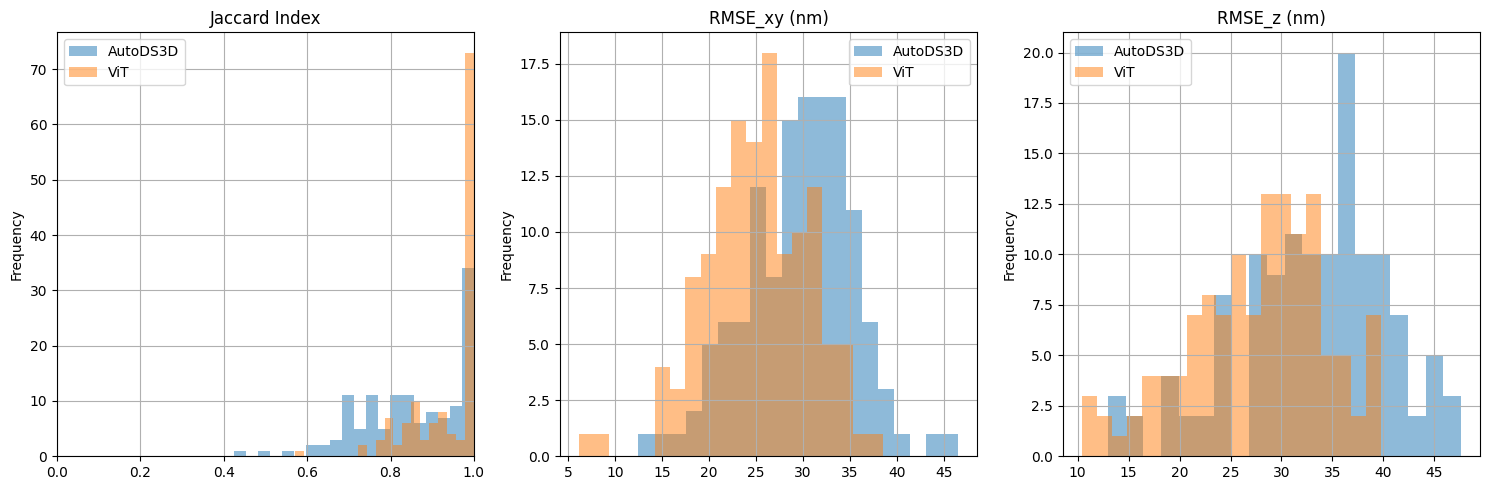

In [ ]:
# Identify numeric columns that are present in both dataframes
numeric_cols = df_autods3d_results.select_dtypes(include=['number']).columns
common_cols = [col for col in numeric_cols if col in df_vit_results.columns]

# Create subplots
fig, axes = plt.subplots(1, len(common_cols), figsize=(5 * len(common_cols), 5))
if len(common_cols) == 1:
    axes = [axes] # Make it iterable if only one plot

# Flatten axes in case of multiple rows (though here it's 1 row)
axes_flat = axes.flatten() if hasattr(axes, 'flatten') else axes

for ax, col in zip(axes_flat, common_cols):
    ax.hist(df_autods3d_results[col], alpha=0.5, label='AutoDS3D', bins=20)
    ax.hist(df_vit_results[col], alpha=0.5, label='ViT', bins=20)
    ax.set_title(col)
    ax.set_ylabel("Frequency")
    if 'Jaccard' in col:
        ax.set_xlim(0, 1)
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

Compare models localizations

In [20]:
autods3d_localizations_path = '/home/dafei/git/AutoDS3D/experiments/mixed_aberration_dataset/localizations_aberrated.csv'
vit_localizations_path = "/home/dafei/output/vitstorm/overfit/results/denoiser_evaluation/128_mixed_images_12_heads_baseline_trained_500k/localizations_encoder_aberrated.csv"

In [21]:
df_autods3d = pd.read_csv(autods3d_localizations_path)
df_vit = pd.read_csv(vit_localizations_path)

if df_autods3d.columns.tolist() != df_vit.columns.tolist():
    raise ValueError("The columns of the two dataframes do not match.")
if df_autods3d.columns.tolist() != ['Image', 'x', 'y', 'z']:
    raise ValueError("The expected columns are: ['Image', 'x', 'y', 'z'].")

In [22]:
data_dir = "/home/dafei/data/ds3d/optical_aberration_pairs/128_imgs/"

In [23]:
output_dir = "/home/dafei/git/AutoDS3D/experiments/model_comparisons_autods3d_vs_encoder_abr_imgs_128_imgs_dataset/"
os.makedirs(output_dir, exist_ok=True)

In [25]:
with open(os.path.join(data_dir, 'y.pickle'), 'rb') as handle:
    localizations = pickle.load(handle)

with open(os.path.join(data_dir, 'param.pickle'), 'rb') as handle:
        param_dict_test_data = pickle.load(handle)

x_folder = os.path.join(data_dir, 'x/abr')

In [34]:
save_aberrated_image_comparison(x_folder, localizations, df_autods3d, df_vit, output_dir)